
Benchmarking AES-GCM-256...
   1KB | Time = 0.0139 ms | Throughput = 70.26 MB/s
 100KB | Time = 0.0616 ms | Throughput = 1585.33 MB/s
 500KB | Time = 0.2749 ms | Throughput = 1775.89 MB/s
   1MB | Time = 0.9808 ms | Throughput = 1019.58 MB/s
   5MB | Time = 3.9824 ms | Throughput = 1255.52 MB/s

Benchmarking AES-GCM-128...
   1KB | Time = 0.0126 ms | Throughput = 77.20 MB/s
 100KB | Time = 0.0569 ms | Throughput = 1714.77 MB/s
 500KB | Time = 0.1926 ms | Throughput = 2535.21 MB/s
   1MB | Time = 0.6689 ms | Throughput = 1495.10 MB/s
   5MB | Time = 4.1288 ms | Throughput = 1211.01 MB/s

Benchmarking ChaCha20-Poly1305...
   1KB | Time = 0.0073 ms | Throughput = 133.78 MB/s
 100KB | Time = 0.0724 ms | Throughput = 1347.91 MB/s
 500KB | Time = 0.2928 ms | Throughput = 1667.91 MB/s
   1MB | Time = 1.0494 ms | Throughput = 952.93 MB/s
   5MB | Time = 4.4737 ms | Throughput = 1117.66 MB/s

Benchmarking AES-CCM-256...
   1KB | Time = 0.0107 ms | Throughput = 91.27 MB/s
 100KB | Time = 0.1275

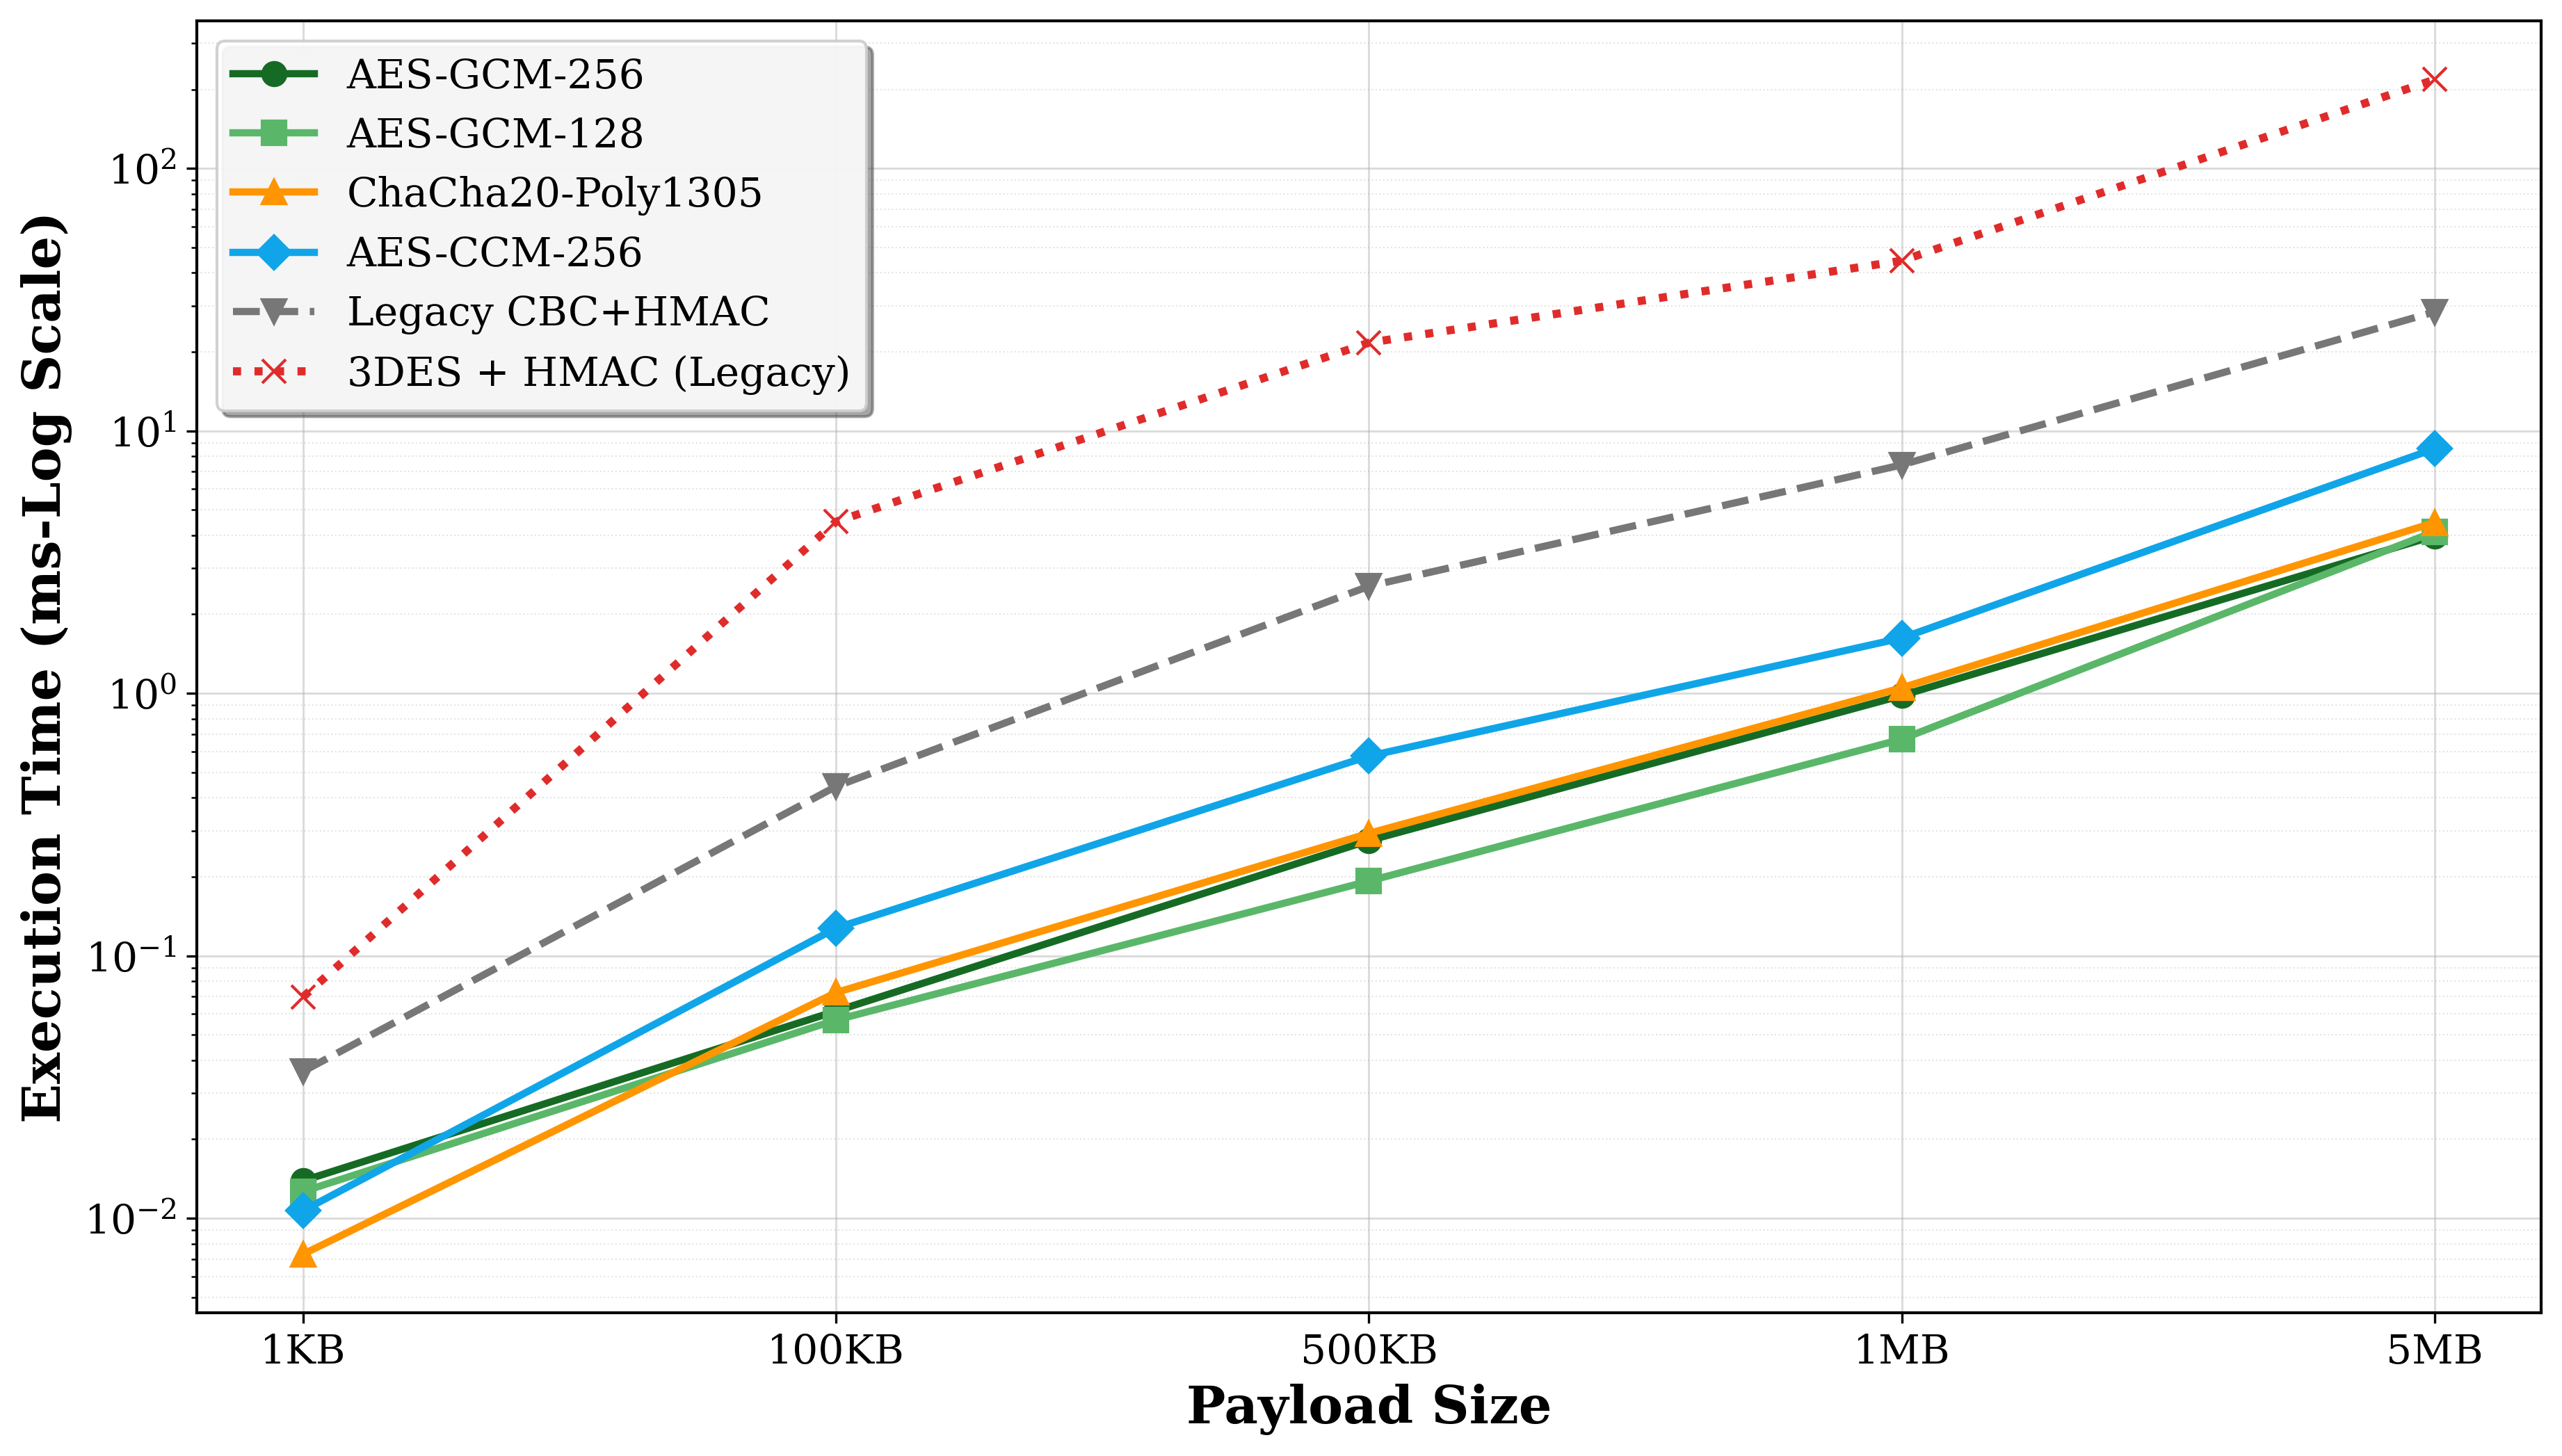

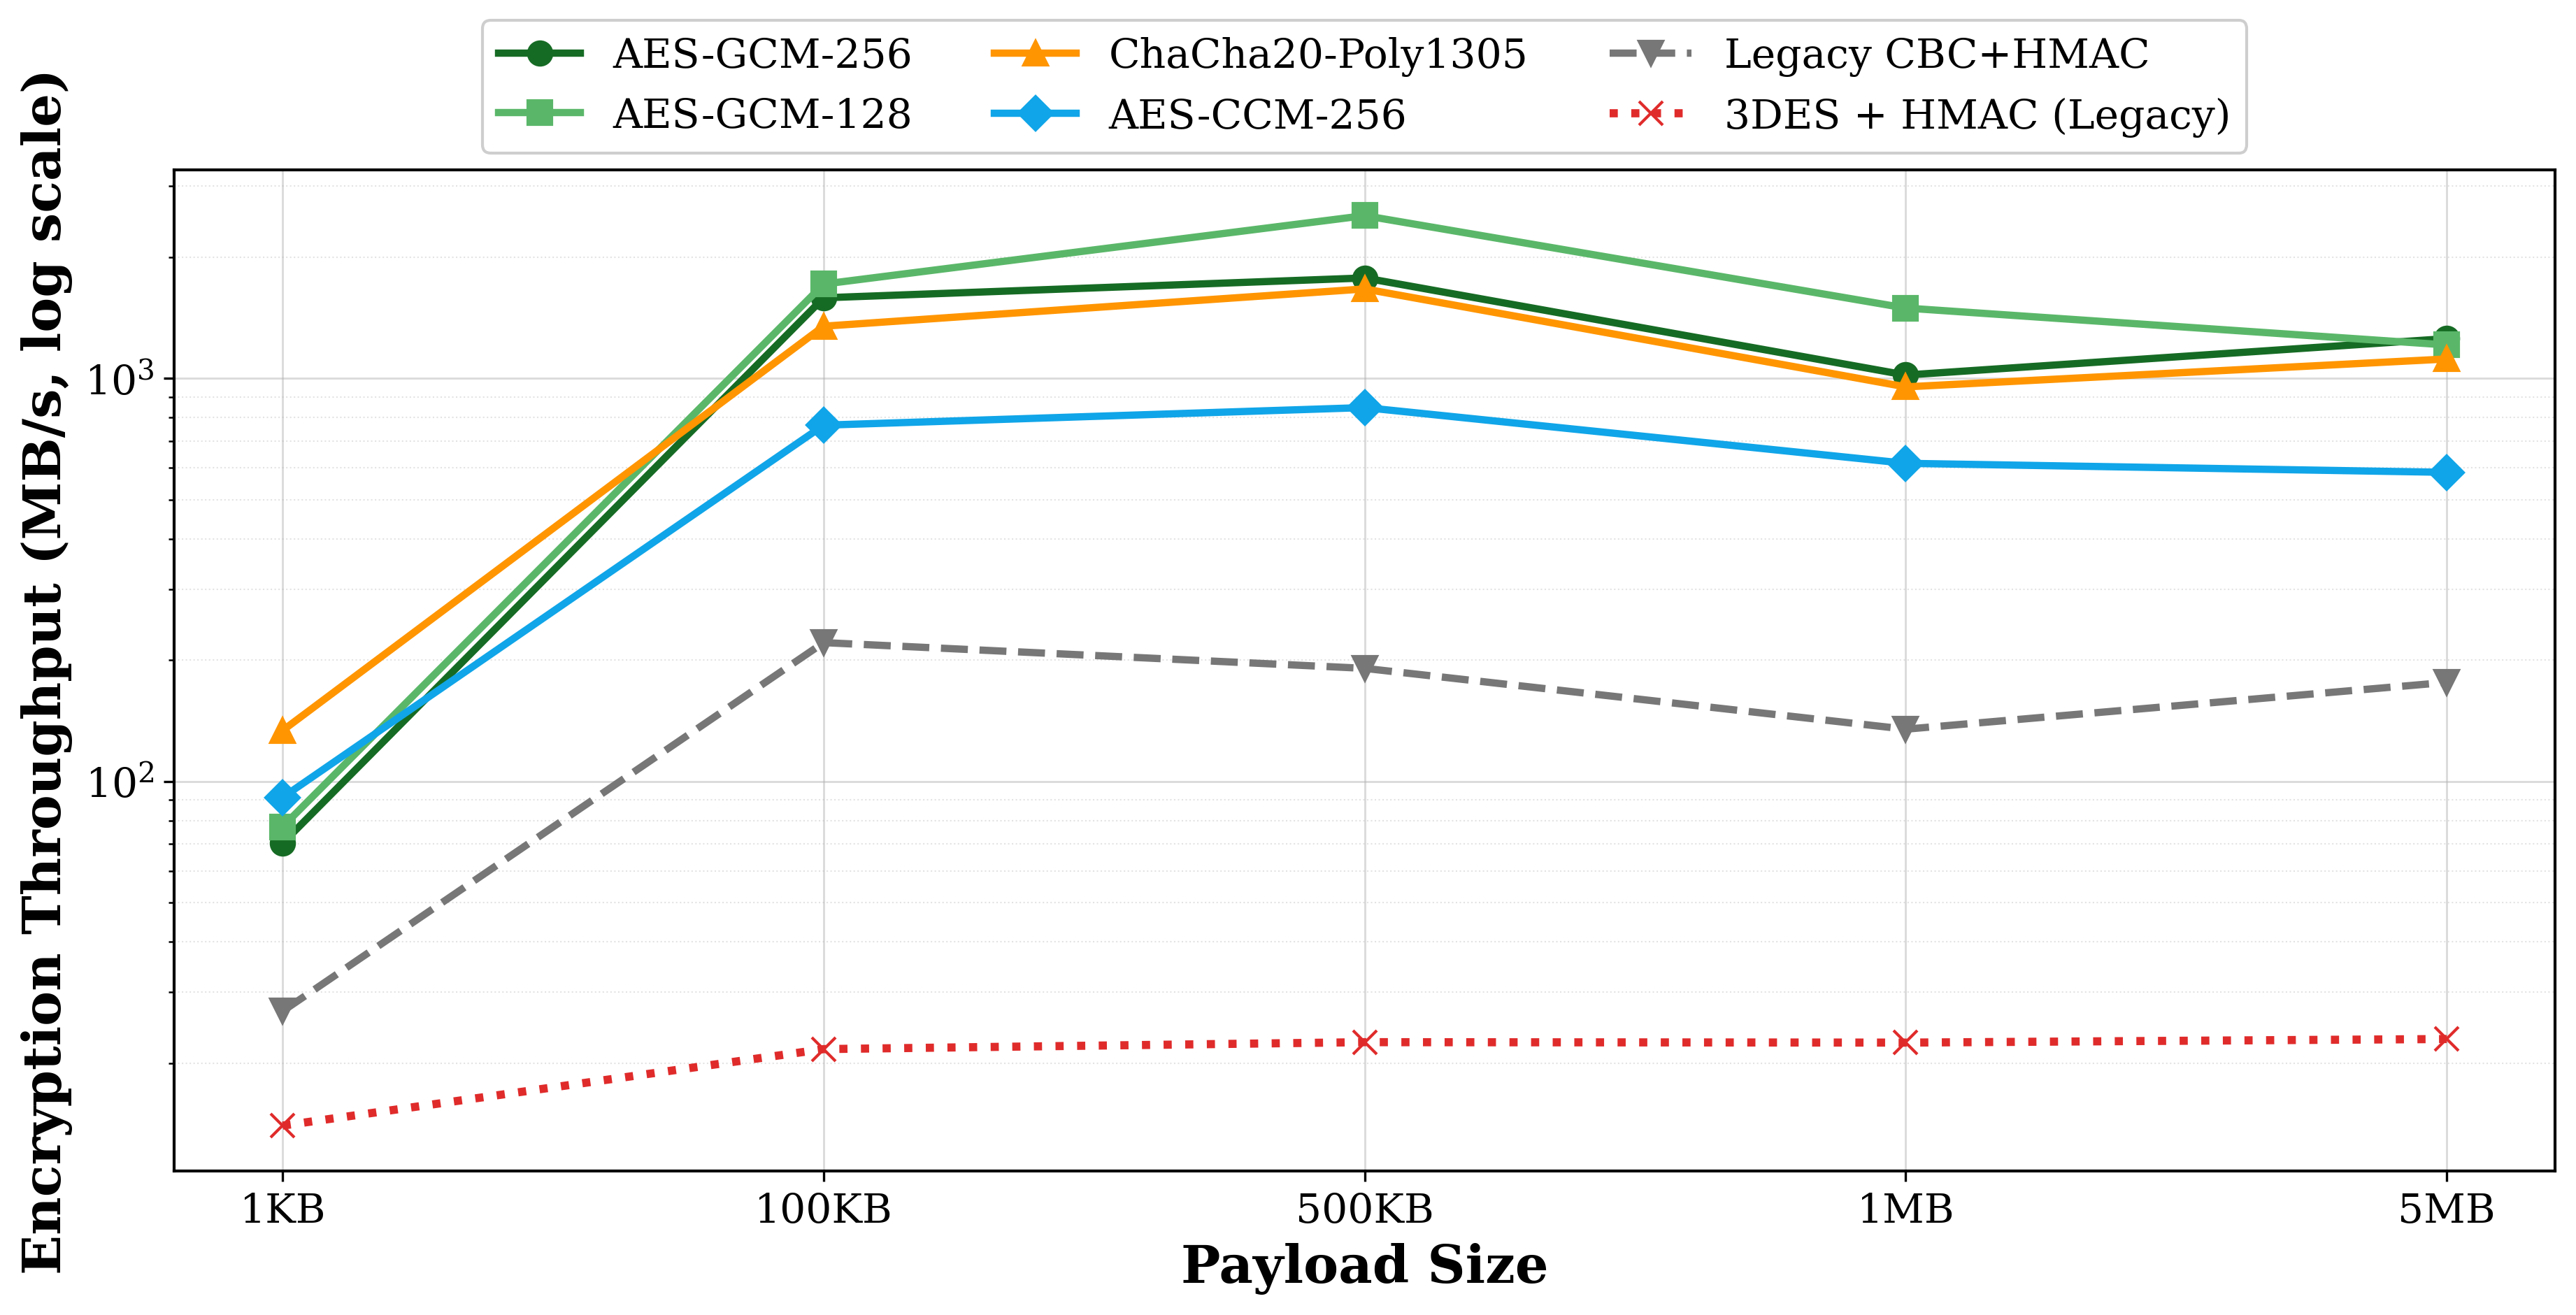

In [38]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

from cryptography.hazmat.primitives.ciphers.aead import AESGCM, ChaCha20Poly1305, AESCCM
from cryptography.hazmat.primitives import hashes, hmac, padding
from cryptography.hazmat.primitives.ciphers import Cipher, algorithms, modes
from cryptography.hazmat.backends import default_backend

# For recent versions of cryptography, TripleDES may be in decrepit
try:
    from cryptography.hazmat.decrepit.ciphers.algorithms import TripleDES
except Exception:
    TripleDES = algorithms.TripleDES


# ============================================================
# Payload sizes
# ============================================================

payload_sizes = {
    "1KB": 1 * 1024,
    "100KB": 100 * 1024,
    "500KB": 500 * 1024,
    "1MB": 1 * 1024 * 1024,
    "5MB": 5 * 1024 * 1024,
}

payload_labels = list(payload_sizes.keys())
x = range(len(payload_labels))


# ============================================================
# Number of repetitions
# More repetitions for small payloads, fewer for large payloads
# ============================================================

def get_repetitions(size_bytes):
    if size_bytes <= 1 * 1024:
        return 300
    elif size_bytes <= 100 * 1024:
        return 100
    elif size_bytes <= 500 * 1024:
        return 50
    elif size_bytes <= 1 * 1024 * 1024:
        return 30
    else:
        return 10


# ============================================================
# Encryption functions
# ============================================================

def encrypt_aes_gcm_256(data, nonce):
    key = os.urandom(32)  # 256-bit key
    aesgcm = AESGCM(key)
    return aesgcm.encrypt(nonce, data, None)


def encrypt_aes_gcm_128(data, nonce):
    key = os.urandom(16)  # 128-bit key
    aesgcm = AESGCM(key)
    return aesgcm.encrypt(nonce, data, None)


def encrypt_chacha20_poly1305(data, nonce):
    key = os.urandom(32)  # 256-bit key
    chacha = ChaCha20Poly1305(key)
    return chacha.encrypt(nonce, data, None)


def encrypt_aes_ccm_256(data, nonce):
    key = os.urandom(32)  # 256-bit key
    aesccm = AESCCM(key, tag_length=16)
    return aesccm.encrypt(nonce, data, None)


def encrypt_legacy_cbc_hmac(data, iv):
    aes_key = os.urandom(32)   # AES-256 key
    hmac_key = os.urandom(32)  # HMAC-SHA256 key

    padder = padding.PKCS7(128).padder()
    padded_data = padder.update(data) + padder.finalize()

    cipher = Cipher(
        algorithms.AES(aes_key),
        modes.CBC(iv),
        backend=default_backend()
    )

    encryptor = cipher.encryptor()
    ciphertext = encryptor.update(padded_data) + encryptor.finalize()

    h = hmac.HMAC(hmac_key, hashes.SHA256())
    h.update(iv + ciphertext)
    tag = h.finalize()

    return ciphertext + tag


def encrypt_3des_hmac_legacy(data, iv):
    des3_key = os.urandom(24)  # 3DES key
    hmac_key = os.urandom(32)  # HMAC-SHA256 key

    padder = padding.PKCS7(64).padder()
    padded_data = padder.update(data) + padder.finalize()

    cipher = Cipher(
        TripleDES(des3_key),
        modes.CBC(iv),
        backend=default_backend()
    )

    encryptor = cipher.encryptor()
    ciphertext = encryptor.update(padded_data) + encryptor.finalize()

    h = hmac.HMAC(hmac_key, hashes.SHA256())
    h.update(iv + ciphertext)
    tag = h.finalize()

    return ciphertext + tag


# ============================================================
# Algorithms
# ============================================================

algorithms_to_test = {
    "AES-GCM-256": {
        "function": encrypt_aes_gcm_256,
        "nonce_size": 12,
    },
    "AES-GCM-128": {
        "function": encrypt_aes_gcm_128,
        "nonce_size": 12,
    },
    "ChaCha20-Poly1305": {
        "function": encrypt_chacha20_poly1305,
        "nonce_size": 12,
    },
    "AES-CCM-256": {
        "function": encrypt_aes_ccm_256,
        "nonce_size": 11,   # corrected for larger payloads
    },
    "Legacy CBC+HMAC": {
        "function": encrypt_legacy_cbc_hmac,
        "nonce_size": 16,
    },
    "3DES + HMAC (Legacy)": {
        "function": encrypt_3des_hmac_legacy,
        "nonce_size": 8,
    },
}


# ============================================================
# Benchmark function
# ============================================================

def benchmark_algorithm(encrypt_function, data, nonce_size, repetitions):
    times_ms = []

    # Pre-generate nonces / IVs to avoid measuring random generation too much
    nonces = [os.urandom(nonce_size) for _ in range(repetitions)]

    # Warm-up
    for i in range(min(3, repetitions)):
        encrypt_function(data, nonces[i])

    for i in range(repetitions):
        start = time.perf_counter()
        encrypt_function(data, nonces[i])
        end = time.perf_counter()

        elapsed_ms = (end - start) * 1000
        times_ms.append(elapsed_ms)

    return np.median(times_ms)


# ============================================================
# Run benchmark
# ============================================================

execution_time_results = {}
throughput_results = {}

for alg_name, alg_info in algorithms_to_test.items():
    execution_time_results[alg_name] = []
    throughput_results[alg_name] = []

    print(f"\nBenchmarking {alg_name}...")

    for label, size_bytes in payload_sizes.items():
        data = os.urandom(size_bytes)
        repetitions = get_repetitions(size_bytes)

        median_time_ms = benchmark_algorithm(
            encrypt_function=alg_info["function"],
            data=data,
            nonce_size=alg_info["nonce_size"],
            repetitions=repetitions
        )

        size_mb = size_bytes / (1024 * 1024)
        time_seconds = median_time_ms / 1000
        throughput_mb_s = size_mb / time_seconds

        execution_time_results[alg_name].append(median_time_ms)
        throughput_results[alg_name].append(throughput_mb_s)

        print(
            f"{label:>6} | "
            f"Time = {median_time_ms:.4f} ms | "
            f"Throughput = {throughput_mb_s:.2f} MB/s"
        )


# ============================================================
# Styles
# ============================================================

styles = {
    "AES-GCM-256": {
        "color": "#166b24",
        "marker": "o",
        "linestyle": "-",
        "linewidth": 2.5,
        "markersize": 8,
    },
    "AES-GCM-128": {
        "color": "#5ab769",
        "marker": "s",
        "linestyle": "-",
        "linewidth": 2.5,
        "markersize": 8,
    },
    "ChaCha20-Poly1305": {
        "color": "#ff9500",
        "marker": "^",
        "linestyle": "-",
        "linewidth": 2.5,
        "markersize": 8,
    },
    "AES-CCM-256": {
        "color": "#10a5e8",
        "marker": "D",
        "linestyle": "-",
        "linewidth": 2.5,
        "markersize": 8,
    },
    "Legacy CBC+HMAC": {
        "color": "#777777",
        "marker": "v",
        "linestyle": "--",
        "linewidth": 2.5,
        "markersize": 8,
    },
    "3DES + HMAC (Legacy)": {
        "color": "#e02b2b",
        "marker": "x",
        "linestyle": ":",
        "linewidth": 2.8,
        "markersize": 8,
    },
}


# ============================================================
# Figure style
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "axes.linewidth": 1.0,
})


# ============================================================
# Plot 1: Execution time
# ============================================================

fig, ax = plt.subplots(figsize=(12.5, 7.2))

for alg_name, values in execution_time_results.items():
    ax.plot(
        x,
        values,
        label=alg_name,
        color=styles[alg_name]["color"],
        marker=styles[alg_name]["marker"],
        linestyle=styles[alg_name]["linestyle"],
        linewidth=styles[alg_name]["linewidth"],
        markersize=styles[alg_name]["markersize"],
    )

ax.set_yscale("log")
ax.set_xticks(list(x))
ax.set_xticklabels(payload_labels)

ax.set_xlabel("Payload Size", fontweight="bold")
ax.set_ylabel("Execution Time (ms-Log Scale)", fontweight="bold")

ax.grid(True, which="major", linestyle="-", linewidth=0.7, alpha=0.45)
ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.35)

ax.legend(
    loc="upper left",
    frameon=True,
    fancybox=True,
    shadow=True,
    framealpha=0.90
)

plt.tight_layout()
plt.savefig("crypto_execution_time_real.png", bbox_inches="tight")
plt.show()


# ============================================================
# Plot 2: Encryption throughput
# ============================================================

fig, ax = plt.subplots(figsize=(12.5, 7.2))

for alg_name, values in throughput_results.items():
    ax.plot(
        x,
        values,
        label=alg_name,
        color=styles[alg_name]["color"],
        marker=styles[alg_name]["marker"],
        linestyle=styles[alg_name]["linestyle"],
        linewidth=styles[alg_name]["linewidth"],
        markersize=styles[alg_name]["markersize"],
    )

ax.set_yscale("log")
ax.set_xticks(list(x))
ax.set_xticklabels(payload_labels)

ax.set_xlabel("Payload Size", fontweight="bold")
ax.set_ylabel("Encryption Throughput (MB/s, log scale)", fontweight="bold")

ax.grid(True, which="major", linestyle="-", linewidth=0.7, alpha=0.45)
ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.35)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.17),
    ncol=3,
    frameon=True,
    fancybox=True,
    shadow=False,
    framealpha=0.95
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("crypto_throughput_real.png", bbox_inches="tight")
plt.show()